<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/lung_cancer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lung Cancer Detection with PyTorch**

* Rio Agustian Gilang Fernando

* Advanced Material Science and Nanotechnology

## 1. Introduction

This notebook is an exercise from PyTorch for Deep Learning Bootcamp, Section 6: PyTorch Custom Datasets. The main purpose of this experiment is to reduce underfitting and to increase model performance.

##2. Underfiting Issue

### 2.1 What is an Underfitting?

Underfitting is when a model cannot capture the variatios present in the training data. The model is too simple.


### 2.2 How to Prevent Underfitting

* Add more layers or units to the model
* Adjust the learning rate
* Use transfer learning
* Traing longer
* Use less regularization

## 3. Import Libraries

In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
import kagglehub
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
from tqdm.auto import tqdm
from time import time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import PyDrive and associated libraries.
# This only needs to be done once in a notebook.
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
# This only needs to be done once in a notebook.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
model_folder = Path("/content/drive/MyDrive/MODELS")

device = "cuda" if torch.cuda.is_available() else "cpu"

## 4. Dataset and DataLoader

The source of the dataset: https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset


### 4.1 Dataset Structure

In [7]:
# Download latest version
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")

print("Path to dataset files:", path)

100%|██████████| 199M/199M [00:01<00:00, 158MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2


In [8]:
print(os.listdir(path))

['Test cases', 'The IQ-OTHNCCD lung cancer dataset']


In [9]:
datasets_path = os.path.join(path, 'The IQ-OTHNCCD lung cancer dataset//The IQ-OTHNCCD lung cancer dataset')
print(os.listdir(datasets_path))

['Malignant cases', 'IQ-OTH_NCCD lung cancer dataset.txt', 'Normal cases', 'Bengin cases']


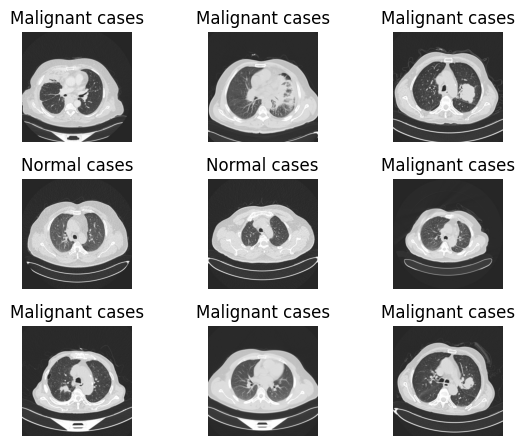

In [10]:
check_dataset = ImageFolder(root=datasets_path, transform=None)

nrows, ncols = 3, 3
class_names = check_dataset.classes
fig = plt.figure()
for i in range(1, nrows*ncols+1):
  rand_idx = torch.randint(0, len(check_dataset), size=[1]).item()
  check_img, check_label = check_dataset[rand_idx]
  fig.add_subplot(nrows, ncols, i)
  plt.imshow(check_img)
  plt.title(class_names[check_label])
  plt.tight_layout()
  plt.axis(False)

### 4.2 Data Transform

In [11]:
# transform for the image, train and test must be different
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
# split it into 3 for easier processing
base_dataset = ImageFolder(root=datasets_path, transform=None)
base_train   = ImageFolder(root=datasets_path, transform=train_transform)
base_test    = ImageFolder(root=datasets_path, transform=test_transform)

def small_dataset(percent):
  # make a smaller dataset
  # get index and label
  labels = [label for _, label in base_dataset.samples]
  indecies = list(range(len(base_dataset)))

  # take N data randomly + stratified
  # we don't use unselected data
  N_data = int(len(base_dataset) * percent) # use 30% data only
  selected_idx, unselected_idx = train_test_split(indecies, train_size=N_data, stratify=labels, random_state=67)
  selected_labels = [labels[i] for i in selected_idx]

  # train test split
  train_idx, test_idx = train_test_split(selected_idx, test_size=0.2, stratify=selected_labels, random_state=67)

  # make subset of train and test
  train_dataset = Subset(base_train, train_idx)
  test_dataset  = Subset(base_test, test_idx)
  return train_dataset, test_dataset

train_dataset, test_dataset = small_dataset(0.3)

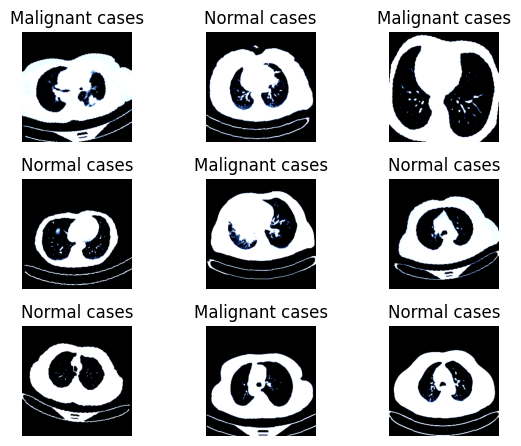

In [13]:
nrows, ncols = 3, 3
class_names = train_dataset.dataset.classes
fig = plt.figure()
for i in range(1, nrows*ncols+1):
  rand_idx = torch.randint(0, len(train_dataset), size=[1]).item()
  check_img, check_label = train_dataset[rand_idx]
  fig.add_subplot(nrows, ncols, i)
  plt.imshow(check_img.permute(1, 2, 0))
  plt.title(class_names[check_label])
  plt.tight_layout()
  plt.axis(False)

### 4.3 DataLoader

In [14]:
# train and test DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

## 5. Model Architecture



We want to replicate the TinyVGG CNN in this site: https://poloclub.github.io/cnn-explainer/

The architecture of the TinyVGG looks like this

`input -> [conv - > relu -> conv -> relu -> max_pool ->] × 2 -> [linear -> relu -> linear]`

Or, it's basically just 2 block of convolution and 1 block of classifier. We will use 10 hidden untits in the beginning.



In [15]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        # nn.AdaptiveAvgPool2d((1, 1)),
        # nn.Flatten(),
        # nn.Linear(in_features=hidden_units,
        #           out_features=output_shape)
        nn.Flatten(),
        nn.LazyLinear(out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x)
    return x

## 6. Training and Testing Pipeline

In [16]:
# train_step() function
def train_step(model, dataloader, loss_fn, optimizer, device=device):
  model.train()
  train_loss, train_acc = 0.0, 0.0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc  = train_acc  / len(dataloader)
  return train_loss, train_acc

# test_step() function
def test_step(model, dataloader, loss_fn, device=device):
  model.eval()
  test_loss, test_acc = 0.0, 0.0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      test_pred_logits = model(X)
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc  += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

  test_loss = test_loss / len(dataloader)
  test_acc  = test_acc  / len(dataloader)
  return test_loss, test_acc

# train() function
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs, device):
  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_loader,
                                    loss_fn=loss_fn,
                                    device=device)
    print(
        f"Epoch: {epoch+1} | "
        f"train loss: {train_loss:.4f} | "
        f"train accuracy: {train_acc:.4f} | "
        f"test loss: {test_loss:.4f} | "
        f"test accuracy: {test_acc:.4f} | "
    )

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

## 7. Experiment 1: The Effect of Number of Epochs

### 7.1 Training for 5 Epochs

In [ ]:
torch.manual_seed(67)
epochs = 5
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(base_dataset.classes)).to(device)
loss_fn_0 = nn.CrossEntropyLoss()
optimizer_0 = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

start = time()

model_0_results = train(model=model_0,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_0,
                        loss_fn=loss_fn_0, epochs=epochs, device=device)
end = time()

time_model_0 = end - start

print(f"\nRunning time: {time_model_0:.4f} seconds")

name_model_0 = "model_0_epoch_5_adam_node_10_dataset_30.pt"
save_path_model_0 = model_folder / name_model_0
torch.save(obj=model_0.state_dict(), f=save_path_model_0)
print(f"\nModel is saved to {save_path_model_0}")

excel_model_0 = pd.DataFrame(model_0_results)
excel_model_0.to_excel("/content/drive/MyDrive/SUMMARY/model_0.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_0}")
excel_model_0

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train loss: 0.9335 | train accuracy: 0.5630 | test loss: 0.7953 | test accuracy: 0.7625 | 
Epoch: 2 | train loss: 0.8413 | train accuracy: 0.6134 | test loss: 0.6975 | test accuracy: 0.7250 | 
Epoch: 3 | train loss: 0.7711 | train accuracy: 0.6586 | test loss: 0.6827 | test accuracy: 0.6875 | 
Epoch: 4 | train loss: 0.7223 | train accuracy: 0.6707 | test loss: 0.6832 | test accuracy: 0.7875 | 
Epoch: 5 | train loss: 0.6536 | train accuracy: 0.7222 | test loss: 0.5859 | test accuracy: 0.8375 | 

Running time: 115.8291 seconds

Model is saved to /content/drive/MyDrive/MODELS/model_0_epoch_5_adam_node_10_dataset_30.pt

Model Excel is saved to /content/drive/MyDrive/MODELS/model_0_epoch_5_adam_node_10_dataset_30.pt


,train_loss,train_acc,test_loss,test_acc
0,0.933521,0.563025,0.795276,0.7625
1,0.841293,0.613445,0.697546,0.7250
2,0.771052,0.658613,0.682725,0.6875
3,0.722346,0.670693,0.683199,0.7875
4,0.653639,0.722164,0.585863,0.8375


### 7.2 Training for 20 epochs

In [ ]:
torch.manual_seed(67)
epochs = 20
model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(base_dataset.classes)).to(device)
loss_fn_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

start = time()

model_1_results = train(model=model_1,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_1,
                        loss_fn=loss_fn_1, epochs=epochs, device=device)
end = time()

time_model_1 = end - start
print(f"\nRunning time: {time_model_1:.4f} seconds")

name_model_1 = "model_1_epoch_20_adam_node_10_dataset_30.pt"
save_path_model_1 = model_folder / name_model_1
torch.save(obj=model_1.state_dict(), f=save_path_model_1)
print(f"Model is saved to {save_path_model_1}")

excel_model_1 = pd.DataFrame(model_1_results)
excel_model_1.to_excel("/content/drive/MyDrive/SUMMARY/model_1.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_0}")
excel_model_1

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 0.9335 | train accuracy: 0.5630 | test loss: 0.7953 | test accuracy: 0.7625 | 
Epoch: 2 | train loss: 0.8413 | train accuracy: 0.6134 | test loss: 0.6975 | test accuracy: 0.7250 | 
Epoch: 3 | train loss: 0.7711 | train accuracy: 0.6586 | test loss: 0.6827 | test accuracy: 0.6875 | 
Epoch: 4 | train loss: 0.7223 | train accuracy: 0.6707 | test loss: 0.6832 | test accuracy: 0.7875 | 
Epoch: 5 | train loss: 0.6536 | train accuracy: 0.7222 | test loss: 0.5859 | test accuracy: 0.8375 | 
Epoch: 6 | train loss: 0.5967 | train accuracy: 0.7453 | test loss: 0.6858 | test accuracy: 0.6625 | 
Epoch: 7 | train loss: 0.5857 | train accuracy: 0.7700 | test loss: 0.5931 | test accuracy: 0.7500 | 
Epoch: 8 | train loss: 0.5816 | train accuracy: 0.7553 | test loss: 0.4934 | test accuracy: 0.8125 | 
Epoch: 9 | train loss: 0.4543 | train accuracy: 0.7994 | test loss: 0.4169 | test accuracy: 0.8500 | 
Epoch: 10 | train loss: 0.5655 | train accuracy: 0.7931 | test loss: 0.3998 | test

### 7.3 Training for 50 Epochs

In [ ]:
torch.manual_seed(67)
epochs = 50
model_2 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(base_dataset.classes)).to(device)
loss_fn_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(params=model_2.parameters(), lr=0.001)

start = time()

model_2_results = train(model=model_2,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_2,
                        loss_fn=loss_fn_2, epochs=epochs, device=device)
end = time()

time_model_2 = end - start
print(f"\nRunning time: {time_model_2:.4f} seconds")

name_model_2 = "model_2_epoch_50_adam_node_10_dataset_30.pt"
save_path_model_2 = model_folder / name_model_2
torch.save(obj=model_2.state_dict(), f=save_path_model_2)
print(f"Model is saved to {save_path_model_2}")

excel_model_2 = pd.DataFrame(model_2_results)
excel_model_2.to_excel("/content/drive/MyDrive/SUMMARY/model_2.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_2}")
excel_model_2

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train loss: 0.9335 | train accuracy: 0.5630 | test loss: 0.7953 | test accuracy: 0.7625 | 
Epoch: 2 | train loss: 0.8413 | train accuracy: 0.6134 | test loss: 0.6975 | test accuracy: 0.7250 | 
Epoch: 3 | train loss: 0.7711 | train accuracy: 0.6586 | test loss: 0.6827 | test accuracy: 0.6875 | 
Epoch: 4 | train loss: 0.7223 | train accuracy: 0.6707 | test loss: 0.6832 | test accuracy: 0.7875 | 
Epoch: 5 | train loss: 0.6536 | train accuracy: 0.7222 | test loss: 0.5859 | test accuracy: 0.8375 | 
Epoch: 6 | train loss: 0.5967 | train accuracy: 0.7453 | test loss: 0.6858 | test accuracy: 0.6625 | 
Epoch: 7 | train loss: 0.5857 | train accuracy: 0.7700 | test loss: 0.5931 | test accuracy: 0.7500 | 
Epoch: 8 | train loss: 0.5816 | train accuracy: 0.7553 | test loss: 0.4934 | test accuracy: 0.8125 | 
Epoch: 9 | train loss: 0.4543 | train accuracy: 0.7994 | test loss: 0.4169 | test accuracy: 0.8500 | 
Epoch: 10 | train loss: 0.5655 | train accuracy: 0.7931 | test loss: 0.3998 | test

,train_loss,train_acc,test_loss,test_acc
0,0.933521,0.563025,0.795276,0.7625
1,0.841293,0.613445,0.697546,0.7250
2,0.771052,0.658613,0.682725,0.6875
3,0.722346,0.670693,0.683199,0.7875
4,0.653639,0.722164,0.585863,0.8375
5,0.596683,0.745273,0.685759,0.6625
6,0.585734,0.769958,0.593123,0.7500
7,0.581632,0.755252,0.493368,0.8125
8,0.454267,0.799370,0.416880,0.8500
9,0.565461,0.793067,0.399808,0.8625


### 7.4 Results and Observation

In [ ]:
summary_0 = []
epochs = [5, 20, 50]
for i, results in enumerate([model_0_results, model_1_results, model_2_results]):
  summary_0.append({
      "epoch": epochs[i],
      "train_loss": results["train_loss"][-1],
      "train_accuracy": results["train_acc"][-1],
      "test_loss": results["test_loss"][-1],
      "test_accuracy": results["test_acc"][-1],
  })

compare_0 = pd.DataFrame(summary_0)
compare_0.to_excel("/content/drive/MyDrive/SUMMARY/compare_0.xlsx", index=True)
compare_0

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,5,0.668129,0.711134,0.643248,0.7375
1,20,0.337327,0.859244,0.473379,0.8375
2,50,0.213304,0.933824,0.496021,0.8125


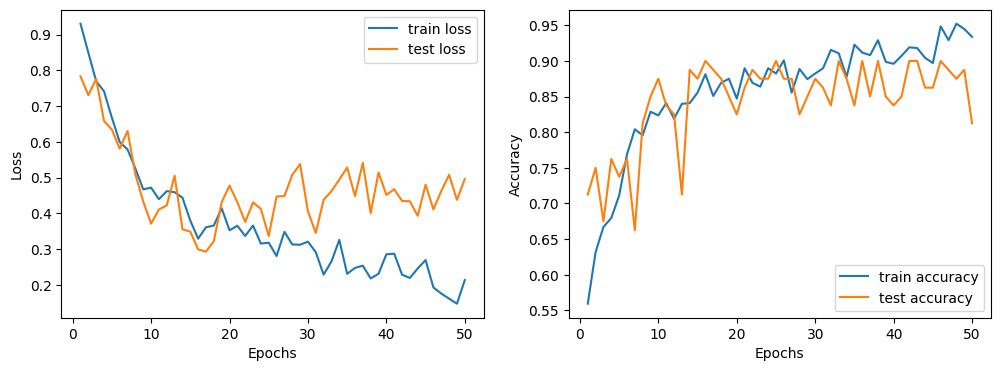

In [ ]:
train_loss_2 = model_2_results["train_loss"]
test_loss_2  = model_2_results["test_loss"]
train_acc_2  = model_2_results["train_acc"]
test_acc_2   = model_2_results["test_acc"]

# loss vs epoch
epochs = range(1, 50+1)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(epochs, train_loss_2, label="train loss")
plt.plot(epochs, test_loss_2, label="test loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(122)
plt.plot(epochs, train_acc_2, label="train accuracy")
plt.plot(epochs, test_acc_2, label="test accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();

In the case for 5 epochs, model shows low performance both in training set and test set. Training loss is still high and accuracy is still low. This indicate that the model not enough learn from the data.

In the case for 20 epochs, there is decreases in training loss that and increases in accuracy. It means that the model is start to catch some important features in the cancer image data. The gap between train and test is still low. The gap increase around 25 epochs.

In the case for 50 epochs, training loss decreases but test loss increases. The training accuracy increases, but the test accuracy decreases. This behavior indicates that our model is overfit.



## 8. Experiment 2: Different Optimizer

### 8.1 Use Stochastic Gradient Descent with Momentum

In [ ]:
torch.manual_seed(67)
epochs = 20
model_3 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(base_dataset.classes)).to(device)
loss_fn_3 = nn.CrossEntropyLoss()
optimizer_3 = torch.optim.SGD(params=model_3.parameters(), lr=0.001, momentum=0.9)

start = time()

model_3_results = train(model=model_3,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_3,
                        loss_fn=loss_fn_3, epochs=epochs, device=device)
end = time()

time_model_3 = end - start
print(f"\nRunning time: {time_model_3:.4f} seconds")

name_model_3 = "model_3_epoch_20_SGD_node_10_dataset_30.pt"
save_path_model_3 = model_folder / name_model_3
torch.save(obj=model_3.state_dict(), f=save_path_model_3)
print(f"\nModel is saved to {save_path_model_3}")

excel_model_3 = pd.DataFrame(model_3_results)
excel_model_3.to_excel("/content/drive/MyDrive/SUMMARY/model_3.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_3}")
excel_model_3

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 1.0214 | train accuracy: 0.4821 | test loss: 0.9265 | test accuracy: 0.5125 | 
Epoch: 2 | train loss: 0.9818 | train accuracy: 0.5021 | test loss: 0.9165 | test accuracy: 0.5125 | 
Epoch: 3 | train loss: 0.9348 | train accuracy: 0.5058 | test loss: 0.8863 | test accuracy: 0.5375 | 
Epoch: 4 | train loss: 0.8983 | train accuracy: 0.6166 | test loss: 0.8442 | test accuracy: 0.7125 | 
Epoch: 5 | train loss: 0.8610 | train accuracy: 0.5888 | test loss: 0.8002 | test accuracy: 0.7125 | 
Epoch: 6 | train loss: 0.8102 | train accuracy: 0.6192 | test loss: 0.8114 | test accuracy: 0.5875 | 
Epoch: 7 | train loss: 0.8071 | train accuracy: 0.6134 | test loss: 0.7302 | test accuracy: 0.7500 | 
Epoch: 8 | train loss: 0.7948 | train accuracy: 0.6366 | test loss: 0.7132 | test accuracy: 0.7500 | 
Epoch: 9 | train loss: 0.7364 | train accuracy: 0.6744 | test loss: 0.6964 | test accuracy: 0.7500 | 
Epoch: 10 | train loss: 0.7213 | train accuracy: 0.7048 | test loss: 0.6757 | test

,train_loss,train_acc,test_loss,test_acc
0,1.021447,0.482143,0.926498,0.5125
1,0.981790,0.502101,0.916503,0.5125
2,0.934821,0.505777,0.886251,0.5375
3,0.898262,0.616597,0.844208,0.7125
4,0.861039,0.588761,0.800181,0.7125
5,0.810233,0.619223,0.811429,0.5875
6,0.807115,0.613445,0.730227,0.7500
7,0.794790,0.636555,0.713189,0.7500
8,0.736438,0.674370,0.696391,0.7500
9,0.721275,0.704832,0.675709,0.7250


### 8.2 Use Stochastic Gradient Descent without Momentum

In [ ]:
torch.manual_seed(67)
epochs = 20
model_4 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(base_dataset.classes)).to(device)
loss_fn_4 = nn.CrossEntropyLoss()
optimizer_4 = torch.optim.SGD(params=model_4.parameters(), lr=0.001, momentum=0)

start = time()

model_4_results = train(model=model_4,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_4,
                        loss_fn=loss_fn_4, epochs=epochs, device=device)
end = time()

time_model_4 = end - start
print(f"\nRunning time: {time_model_4:.4f} seconds")

name_model_4 = "model_4_epoch_20_SGD_no_mom_node_10_dataset_30.pt"
save_path_model_4 = model_folder / name_model_4
torch.save(obj=model_4.state_dict(), f=save_path_model_4)
print(f"\nModel is saved to {save_path_model_4}")

excel_model_4 = pd.DataFrame(model_4_results)
excel_model_4.to_excel("/content/drive/MyDrive/SUMMARY/model_4.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_4}")
excel_model_4

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 1.0813 | train accuracy: 0.4527 | test loss: 1.0548 | test accuracy: 0.5125 | 
Epoch: 2 | train loss: 1.0409 | train accuracy: 0.5021 | test loss: 1.0112 | test accuracy: 0.5125 | 
Epoch: 3 | train loss: 1.0023 | train accuracy: 0.5021 | test loss: 0.9732 | test accuracy: 0.5125 | 
Epoch: 4 | train loss: 0.9733 | train accuracy: 0.5116 | test loss: 0.9476 | test accuracy: 0.5125 | 
Epoch: 5 | train loss: 0.9569 | train accuracy: 0.5210 | test loss: 0.9340 | test accuracy: 0.5125 | 
Epoch: 6 | train loss: 0.9527 | train accuracy: 0.5116 | test loss: 0.9270 | test accuracy: 0.5125 | 
Epoch: 7 | train loss: 0.9530 | train accuracy: 0.5116 | test loss: 0.9234 | test accuracy: 0.5125 | 
Epoch: 8 | train loss: 0.9544 | train accuracy: 0.5068 | test loss: 0.9206 | test accuracy: 0.5125 | 
Epoch: 9 | train loss: 0.9479 | train accuracy: 0.5163 | test loss: 0.9184 | test accuracy: 0.5125 | 
Epoch: 10 | train loss: 0.9436 | train accuracy: 0.5068 | test loss: 0.9153 | test

,train_loss,train_acc,test_loss,test_acc
0,1.081327,0.452731,1.054800,0.5125
1,1.040904,0.502101,1.011243,0.5125
2,1.002303,0.502101,0.973242,0.5125
3,0.973313,0.511555,0.947624,0.5125
4,0.956933,0.521008,0.934004,0.5125
5,0.952673,0.511555,0.927041,0.5125
6,0.952960,0.511555,0.923385,0.5125
7,0.954426,0.506828,0.920591,0.5125
8,0.947865,0.516282,0.918388,0.5125
9,0.943641,0.506828,0.915281,0.5125


### 8.3 Results and Observations

In [ ]:
summary_1 = []
optimizer = ["Adam", "SGD momentum 0.9", "SGD no momentum"]
for i, results in enumerate([model_1_results, model_3_results, model_4_results]):
  summary_1.append({
      "optimizer": optimizer[i],
      "train_loss": results["train_loss"][-1],
      "train_accuracy": results["train_acc"][-1],
      "test_loss": results["test_loss"][-1],
      "test_accuracy": results["test_acc"][-1],
  })

compare_1 = pd.DataFrame(summary_1)
compare_1.to_excel("/content/drive/MyDrive/SUMMARY/compare_1.xlsx", index=True)
compare_1

,optimizer,train_loss,train_accuracy,test_loss,test_accuracy
0,Adam,0.337327,0.859244,0.473379,0.8375
1,SGD momentum 0.9,0.564315,0.766282,0.566118,0.8125
2,SGD no momentum,0.902362,0.559349,0.864240,0.7000


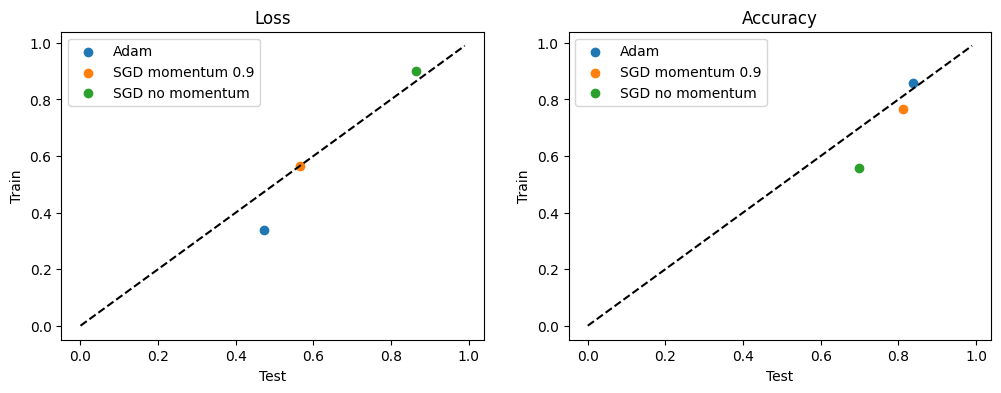

In [ ]:
train_loss_1 = model_2_results["train_loss"]
test_loss_1  = model_2_results["test_loss"]
train_acc_2  = model_2_results["train_acc"]
test_acc_2   = model_2_results["test_acc"]

models = [model_1_results, model_3_results, model_4_results]

plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01), c="black", ls="--")

plt.subplot(122)
plt.plot(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01), c="black", ls="--")

for i in range(3):
  train_loss = models[i]["train_loss"][-1]
  test_loss  = models[i]["test_loss"][-1]
  train_acc  = models[i]["train_acc"][-1]
  test_acc   = models[i]["test_acc"][-1]

  plt.subplot(121)
  plt.title("Loss")
  plt.scatter(test_loss, train_loss, label=f"{optimizer[i]}")
  plt.xlabel("Test")
  plt.ylabel("Train")
  plt.legend()

  plt.subplot(122)
  plt.title("Accuracy")
  plt.scatter(test_acc, train_acc, label=f"{optimizer[i]}")
  plt.xlabel("Test")
  plt.ylabel("Train")
  plt.legend()

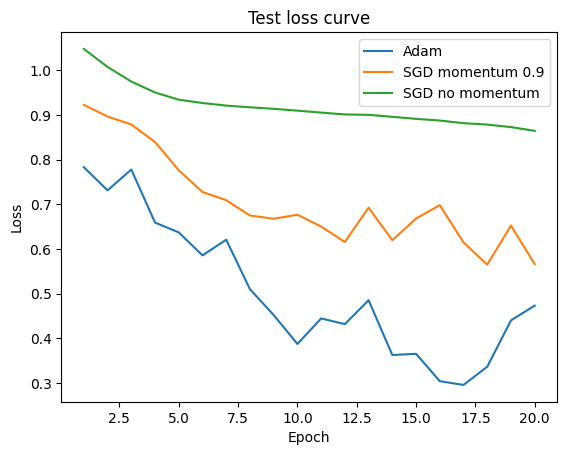

In [ ]:
plt.figure()

for i in range(3):
  test_loss  = models[i]["test_loss"]
  plt.plot(range(1, 20+1), test_loss, label=f"{optimizer[i]}")
  plt.title("Test loss curve")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

Adam optimizer shows fastest convergence. Adam stated with lowest loss and decreeasred fastest compare to other optimizer. Adam achieved the lowest loss around 17th epoch, better than the others two optimizer. After 17th epoch, loss in Adam increase again (from 0.3 tp 0.5 in 20th epoch) This is the early sign of overfitting. Model is started to memorize the training data set and the performance in test data decreases. Or, we can adjjst the learning rate so that the model can stay in the global minimum.

SGD with moementum of 0.9 has middle perfromence. Adding momentum really helps compare to regular SGD, but not as accurate as Adam in 20 epochs.The loss looks unstable (fluctiative) after 12 epochs. This can be the sign of learning rate is too big near the end of training.

SGD without momentum is the slowest. The graph decreaes slowly. In the 2oth epoch, the loss is still quite high (around 0.9). This shows that the model learn with too small step. Without momentum, algorithm can stuk in the flat area of the loss surface and needs a very long time to decrease.




## 9. Experiment 3: Add Model Complexity

### 9.1 Use 20 Hidden Units

In [ ]:
torch.manual_seed(67)
epochs = 20
model_5 = TinyVGG(input_shape=3, hidden_units=20, output_shape=len(base_dataset.classes)).to(device)
loss_fn_5 = nn.CrossEntropyLoss()
optimizer_5 = torch.optim.Adam(params=model_5.parameters(), lr=0.001)

start = time()

model_5_results = train(model=model_5,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_5,
                        loss_fn=loss_fn_5, epochs=epochs, device=device)
end = time()

time_model_5 = end - start
print(f"\nRunning time: {time_model_5:.4f} seconds")

name_model_5 = "model_5_epoch_20_adam_node_20_dataset_30.pt"
save_path_model_5 = model_folder / name_model_5
torch.save(obj=model_5.state_dict(), f=save_path_model_5)
print(f"\nModel is saved to {save_path_model_5}")

excel_model_5 = pd.DataFrame(model_5_results)
excel_model_5.to_excel("/content/drive/MyDrive/SUMMARY/model_5.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_5}")
excel_model_5

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 1.0737 | train accuracy: 0.4979 | test loss: 0.9149 | test accuracy: 0.5125 | 
Epoch: 2 | train loss: 0.8848 | train accuracy: 0.6303 | test loss: 0.8627 | test accuracy: 0.5375 | 
Epoch: 3 | train loss: 0.8631 | train accuracy: 0.5987 | test loss: 0.8167 | test accuracy: 0.5625 | 
Epoch: 4 | train loss: 0.7242 | train accuracy: 0.6854 | test loss: 0.6601 | test accuracy: 0.7250 | 
Epoch: 5 | train loss: 0.7263 | train accuracy: 0.6928 | test loss: 0.7638 | test accuracy: 0.6500 | 
Epoch: 6 | train loss: 0.6865 | train accuracy: 0.6954 | test loss: 0.6478 | test accuracy: 0.7250 | 
Epoch: 7 | train loss: 0.6430 | train accuracy: 0.7148 | test loss: 0.4647 | test accuracy: 0.7875 | 
Epoch: 8 | train loss: 0.5909 | train accuracy: 0.7111 | test loss: 0.4970 | test accuracy: 0.8125 | 
Epoch: 9 | train loss: 0.4693 | train accuracy: 0.8162 | test loss: 0.5921 | test accuracy: 0.7500 | 
Epoch: 10 | train loss: 0.5028 | train accuracy: 0.7673 | test loss: 0.5944 | test

,train_loss,train_acc,test_loss,test_acc
0,1.073734,0.497899,0.914943,0.5125
1,0.884799,0.630252,0.862727,0.5375
2,0.863103,0.598739,0.816684,0.5625
3,0.724191,0.685399,0.660099,0.7250
4,0.726325,0.692752,0.763819,0.6500
5,0.686531,0.695378,0.647796,0.7250
6,0.643040,0.714811,0.464734,0.7875
7,0.590935,0.711134,0.496966,0.8125
8,0.469301,0.816176,0.592059,0.7500
9,0.502844,0.767332,0.594413,0.7000


### 9.2 Use 40 Hidden Units

In [ ]:
torch.manual_seed(67)
epochs = 20
model_6 = TinyVGG(input_shape=3, hidden_units=40, output_shape=len(base_dataset.classes)).to(device)
loss_fn_6 = nn.CrossEntropyLoss()
optimizer_6 = torch.optim.Adam(params=model_6.parameters(), lr=0.001)

start = time()

model_6_results = train(model=model_6,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_6,
                        loss_fn=loss_fn_6, epochs=epochs, device=device)
end = time()

time_model_6 = end - start
print(f"\nRunning time: {time_model_6:.4f} seconds")

name_model_6 = "model_6_epoch_20_adam_node_40_dataset_30.pt"
save_path_model_6 = model_folder / name_model_6
torch.save(obj=model_6.state_dict(), f=save_path_model_6)
print(f"\nModel is saved to {save_path_model_6}")

excel_model_6 = pd.DataFrame(model_6_results)
excel_model_6.to_excel("/content/drive/MyDrive/SUMMARY/model_6.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_6}")
excel_model_6

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 1.1169 | train accuracy: 0.4286 | test loss: 0.9013 | test accuracy: 0.5125 | 
Epoch: 2 | train loss: 0.8612 | train accuracy: 0.6145 | test loss: 0.6949 | test accuracy: 0.7750 | 
Epoch: 3 | train loss: 0.8410 | train accuracy: 0.6576 | test loss: 0.7079 | test accuracy: 0.7375 | 
Epoch: 4 | train loss: 0.7799 | train accuracy: 0.6534 | test loss: 0.6877 | test accuracy: 0.7250 | 
Epoch: 5 | train loss: 0.7025 | train accuracy: 0.7306 | test loss: 0.6418 | test accuracy: 0.7125 | 
Epoch: 6 | train loss: 0.6693 | train accuracy: 0.7148 | test loss: 0.5546 | test accuracy: 0.7625 | 
Epoch: 7 | train loss: 0.6611 | train accuracy: 0.7211 | test loss: 0.5706 | test accuracy: 0.8250 | 
Epoch: 8 | train loss: 0.5868 | train accuracy: 0.7222 | test loss: 0.6108 | test accuracy: 0.7750 | 
Epoch: 9 | train loss: 0.6410 | train accuracy: 0.7358 | test loss: 0.5916 | test accuracy: 0.8375 | 
Epoch: 10 | train loss: 0.5517 | train accuracy: 0.7920 | test loss: 0.8578 | test

,train_loss,train_acc,test_loss,test_acc
0,1.116933,0.428571,0.901311,0.5125
1,0.861155,0.614496,0.694914,0.7750
2,0.841027,0.657563,0.707873,0.7375
3,0.779913,0.653361,0.687734,0.7250
4,0.702464,0.730567,0.641778,0.7125
5,0.669272,0.714811,0.554576,0.7625
6,0.661078,0.721113,0.570553,0.8250
7,0.586817,0.722164,0.610828,0.7750
8,0.641036,0.735819,0.591558,0.8375
9,0.551700,0.792017,0.857833,0.6125


### 9.3 Use 80 Hidden Units

In [ ]:
torch.manual_seed(67)
epochs = 20
model_7 = TinyVGG(input_shape=3, hidden_units=80, output_shape=len(base_dataset.classes)).to(device)
loss_fn_7 = nn.CrossEntropyLoss()
optimizer_7 = torch.optim.Adam(params=model_7.parameters(), lr=0.001)

start = time()

model_7_results = train(model=model_7,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_7,
                        loss_fn=loss_fn_7, epochs=epochs, device=device)
end = time()

time_model_7 = end - start
print(f"\nRunning time: {time_model_7:.4f} seconds")

name_model_7 = "model_7_epoch_20_adam_node_80_dataset_30.pt"
save_path_model_7 = model_folder / name_model_7
torch.save(obj=model_7.state_dict(), f=save_path_model_7)
print(f"\nModel is saved to {save_path_model_7}")

excel_model_7 = pd.DataFrame(model_7_results)
excel_model_7.to_excel("/content/drive/MyDrive/SUMMARY/model_7.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_7}")
excel_model_7

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 1.5894 | train accuracy: 0.4722 | test loss: 0.8720 | test accuracy: 0.5125 | 
Epoch: 2 | train loss: 0.8786 | train accuracy: 0.6061 | test loss: 0.9390 | test accuracy: 0.6375 | 
Epoch: 3 | train loss: 0.8154 | train accuracy: 0.5987 | test loss: 0.8410 | test accuracy: 0.5750 | 
Epoch: 4 | train loss: 0.7774 | train accuracy: 0.6880 | test loss: 0.7392 | test accuracy: 0.7000 | 
Epoch: 5 | train loss: 0.7536 | train accuracy: 0.6880 | test loss: 0.6980 | test accuracy: 0.7125 | 
Epoch: 6 | train loss: 0.7291 | train accuracy: 0.6796 | test loss: 0.5691 | test accuracy: 0.8000 | 
Epoch: 7 | train loss: 0.7637 | train accuracy: 0.6723 | test loss: 0.6751 | test accuracy: 0.7250 | 
Epoch: 8 | train loss: 0.6935 | train accuracy: 0.7164 | test loss: 0.7382 | test accuracy: 0.7375 | 
Epoch: 9 | train loss: 0.6363 | train accuracy: 0.7195 | test loss: 0.5486 | test accuracy: 0.8125 | 
Epoch: 10 | train loss: 0.6733 | train accuracy: 0.6917 | test loss: 0.5487 | test

,train_loss,train_acc,test_loss,test_acc
0,1.589359,0.472164,0.871996,0.5125
1,0.878617,0.606092,0.939046,0.6375
2,0.815414,0.598739,0.841029,0.5750
3,0.777387,0.688025,0.739227,0.7000
4,0.753639,0.688025,0.698008,0.7125
5,0.729112,0.679622,0.569104,0.8000
6,0.763732,0.672269,0.675084,0.7250
7,0.693477,0.716387,0.738209,0.7375
8,0.636337,0.719538,0.548590,0.8125
9,0.673308,0.691702,0.548733,0.8250


### 9.4 Results and Observation

In [ ]:
summary_2 = []
hidden_units = [10, 20, 40, 80]
for i, results in enumerate([model_1_results, model_5_results, model_6_results, model_7_results]):
  summary_2.append({
      "hidden_units": hidden_units[i],
      "train_loss": results["train_loss"][-1],
      "train_accuracy": results["train_acc"][-1],
      "test_loss": results["test_loss"][-1],
      "test_accuracy": results["test_acc"][-1],
  })

compare_2 = pd.DataFrame(summary_2)

def count_params(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

models = [model_1, model_5, model_6, model_7]
parameters = [count_params(param) for param in models]
compare_2["parameters"] = parameters

compare_2.to_excel("/content/drive/MyDrive/SUMMARY/compare2.xlsx", index=True)
compare_2

In [ ]:
df_compare_2 = pd.read_excel("/content/drive/MyDrive/SUMMARY/compare2.xlsx")
df_compare_2

,Unnamed: 0,hidden_units,train_loss,train_accuracy,test_loss,test_accuracy,parameters
0,0,10,0.339900,0.863971,0.482106,0.8375,93763
1,1,20,0.373812,0.847164,0.343240,0.9125,192923
2,2,40,0.440078,0.828782,0.420936,0.8625,407443
3,3,80,0.398490,0.860294,0.565961,0.7875,901283


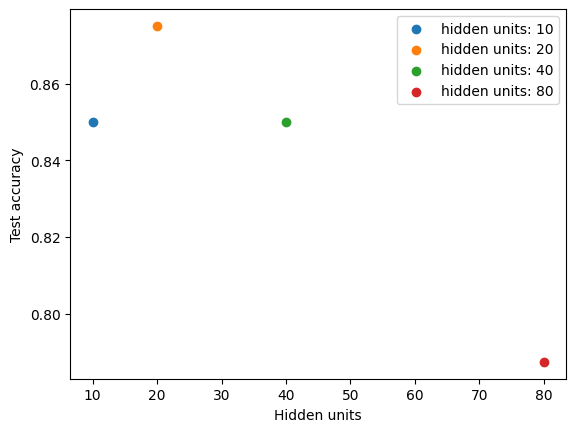

In [ ]:
df_model_1 = pd.read_excel("/content/drive/MyDrive/SUMMARY/model_1.xlsx")
df_model_5 = pd.read_excel("/content/drive/MyDrive/SUMMARY/model_5.xlsx")
df_model_6 = pd.read_excel("/content/drive/MyDrive/SUMMARY/model_6.xlsx")
df_model_7 = pd.read_excel("/content/drive/MyDrive/SUMMARY/model_7.xlsx")

hidden_units = [10, 20, 40, 80]
models = [df_model_1, df_model_5, df_model_6, df_model_7]
plt.figure()
for i in range(len(models)):
  x = hidden_units[i]
  y = models[i]["test_acc"].iloc[-1]
  plt.scatter(x, y, label=f"hidden units: {hidden_units[i]}")
  plt.xlabel("Hidden units")
  plt.ylabel("Test accuracy")
  plt.legend()

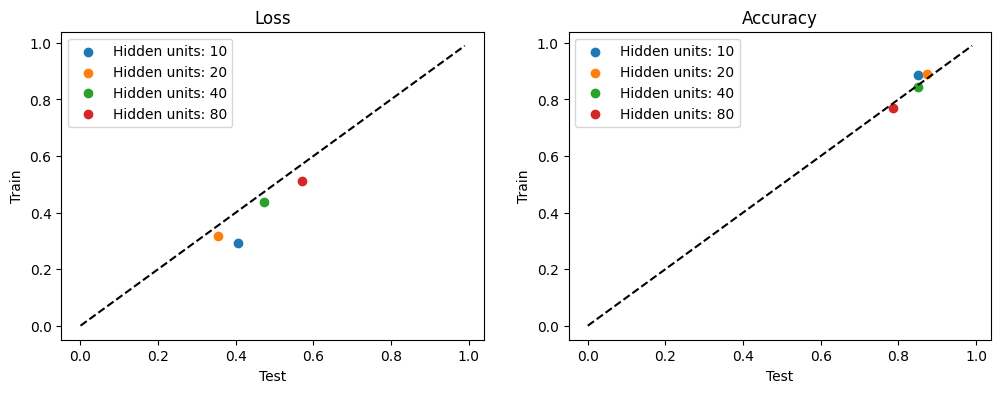

In [ ]:
hidden_units = [10, 20, 40, 80]
models = [df_model_1, df_model_5, df_model_6, df_model_7]

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01), c="black", ls="--")
plt.subplot(122)
plt.plot(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01), c="black", ls="--")

for i in range(len(hidden_units)):
  train_loss = models[i]["train_loss"].iloc[-1]
  test_loss  = models[i]["test_loss"].iloc[-1]
  train_acc  = models[i]["train_acc"].iloc[-1]
  test_acc   = models[i]["test_acc"].iloc[-1]

  plt.subplot(121)
  plt.title("Loss")
  plt.scatter(test_loss, train_loss, label=f"Hidden units: {hidden_units[i]}")
  plt.xlabel("Test")
  plt.ylabel("Train")
  plt.legend()

  plt.subplot(122)
  plt.title("Accuracy")
  plt.scatter(test_acc, train_acc, label=f"Hidden units: {hidden_units[i]}")
  plt.xlabel("Test")
  plt.ylabel("Train")
  plt.legend()

The hidden units of 10 achieved the lowest train loss, but it has higher test loss compare to hidden units of 20. The gap between training loss and test loss of 20 nodes is smaller compare to 10 nodes. The 20 nodes alos achiebved the highest training and test accuracy. After 20 nodes, the model experiences overfit.

## 10. Experiment 4: Use More Data

### 10.1 Use 50 % of the Data

In [ ]:
train_dataset, test_dataset = small_dataset(0.5)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

torch.manual_seed(67)
epochs = 20
model_8 = TinyVGG(input_shape=3, hidden_units=20, output_shape=len(base_dataset.classes)).to(device)
loss_fn_8 = nn.CrossEntropyLoss()
optimizer_8 = torch.optim.Adam(params=model_8.parameters(), lr=0.001)

start = time()

model_8_results = train(model=model_8,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_8,
                        loss_fn=loss_fn_8, epochs=epochs, device=device)
end = time()

time_model_8 = end - start
print(f"\nRunning time: {time_model_8:.4f} seconds")

name_model_8 = "model_8_epoch_20_adam_node_10_dataset_50.pt"
save_path_model_8 = model_folder / name_model_8
torch.save(obj=model_8.state_dict(), f=save_path_model_8)
print(f"Model is saved to {save_path_model_8}")

excel_model_8 = pd.DataFrame(model_8_results)
excel_model_8.to_excel("/content/drive/MyDrive/SUMMARY/model_8.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_8}")
excel_model_8

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 0.9888 | train accuracy: 0.5320 | test loss: 0.7848 | test accuracy: 0.6722 | 
Epoch: 2 | train loss: 0.8323 | train accuracy: 0.6168 | test loss: 0.8255 | test accuracy: 0.6263 | 
Epoch: 3 | train loss: 0.7426 | train accuracy: 0.7039 | test loss: 0.7307 | test accuracy: 0.7283 | 
Epoch: 4 | train loss: 0.6619 | train accuracy: 0.7173 | test loss: 0.6538 | test accuracy: 0.7653 | 
Epoch: 5 | train loss: 0.6688 | train accuracy: 0.7225 | test loss: 0.6831 | test accuracy: 0.7283 | 
Epoch: 6 | train loss: 0.6116 | train accuracy: 0.7552 | test loss: 0.5970 | test accuracy: 0.8023 | 
Epoch: 7 | train loss: 0.5944 | train accuracy: 0.7686 | test loss: 0.5084 | test accuracy: 0.7934 | 
Epoch: 8 | train loss: 0.5542 | train accuracy: 0.7738 | test loss: 0.4561 | test accuracy: 0.8010 | 
Epoch: 9 | train loss: 0.4979 | train accuracy: 0.8021 | test loss: 0.5699 | test accuracy: 0.7640 | 
Epoch: 10 | train loss: 0.5028 | train accuracy: 0.8125 | test loss: 0.4184 | test

,train_loss,train_acc,test_loss,test_acc
0,0.988762,0.531994,0.784781,0.672194
1,0.832328,0.616815,0.825510,0.626276
2,0.742566,0.703869,0.730728,0.728316
3,0.661851,0.717262,0.653771,0.765306
4,0.668823,0.722470,0.683114,0.728316
5,0.611581,0.755208,0.596982,0.802296
6,0.594360,0.768601,0.508380,0.793367
7,0.554237,0.773810,0.456061,0.801020
8,0.497945,0.802083,0.569943,0.764031
9,0.502751,0.812500,0.418397,0.866071


### 10.2 Use 70 % of the Data

In [ ]:
train_dataset, test_dataset = small_dataset(0.7)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

torch.manual_seed(67)
epochs = 20
model_9 = TinyVGG(input_shape=3, hidden_units=20, output_shape=len(base_dataset.classes)).to(device)
loss_fn_9 = nn.CrossEntropyLoss()
optimizer_9 = torch.optim.Adam(params=model_9.parameters(), lr=0.001)

start = time()

model_9_results = train(model=model_9,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_9,
                        loss_fn=loss_fn_9, epochs=epochs, device=device)
end = time()

time_model_9 = end - start
print(f"\nRunning time: {time_model_9:.4f} seconds")

name_model_9 = "model_9_epoch_20_adam_node_20_dataset_70.pt"
save_path_model_9 = model_folder / name_model_9
torch.save(obj=model_9.state_dict(), f=save_path_model_9)
print(f"Model is saved to {save_path_model_9}")

excel_model_9 = pd.DataFrame(model_9_results)
excel_model_9.to_excel("/content/drive/MyDrive/SUMMARY/model_9.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_9}")
excel_model_9

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 0.9310 | train accuracy: 0.5590 | test loss: 0.7567 | test accuracy: 0.7213 | 
Epoch: 2 | train loss: 0.7410 | train accuracy: 0.7019 | test loss: 0.6091 | test accuracy: 0.7588 | 
Epoch: 3 | train loss: 0.6475 | train accuracy: 0.7388 | test loss: 0.5258 | test accuracy: 0.8025 | 
Epoch: 4 | train loss: 0.5922 | train accuracy: 0.7548 | test loss: 0.4627 | test accuracy: 0.8313 | 
Epoch: 5 | train loss: 0.5446 | train accuracy: 0.7750 | test loss: 0.3676 | test accuracy: 0.8688 | 
Epoch: 6 | train loss: 0.5313 | train accuracy: 0.7750 | test loss: 0.3874 | test accuracy: 0.8150 | 
Epoch: 7 | train loss: 0.4511 | train accuracy: 0.8221 | test loss: 0.4988 | test accuracy: 0.8088 | 
Epoch: 8 | train loss: 0.4569 | train accuracy: 0.8119 | test loss: 0.2834 | test accuracy: 0.8812 | 
Epoch: 9 | train loss: 0.4052 | train accuracy: 0.8429 | test loss: 0.2825 | test accuracy: 0.8938 | 
Epoch: 10 | train loss: 0.3740 | train accuracy: 0.8551 | test loss: 0.3709 | test

,train_loss,train_acc,test_loss,test_acc
0,0.930955,0.558974,0.756656,0.72125
1,0.741008,0.701923,0.609137,0.75875
2,0.647522,0.738782,0.525827,0.80250
3,0.592231,0.754808,0.462713,0.83125
4,0.544630,0.775000,0.367634,0.86875
5,0.531331,0.775000,0.387395,0.81500
6,0.451066,0.822115,0.498807,0.80875
7,0.456942,0.811859,0.283384,0.88125
8,0.405160,0.842949,0.282466,0.89375
9,0.373965,0.855128,0.370884,0.85000


### 10.1 Use 100 % of the Data

In [ ]:
train_dataset, test_dataset = small_dataset(0.95)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

torch.manual_seed(67)
epochs = 20
model_10 = TinyVGG(input_shape=3, hidden_units=20, output_shape=len(base_dataset.classes)).to(device)
loss_fn_10 = nn.CrossEntropyLoss()
optimizer_10 = torch.optim.Adam(params=model_10.parameters(), lr=0.001)

start = time()

model_10_results = train(model=model_10,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer_10,
                        loss_fn=loss_fn_10, epochs=epochs, device=device)
end = time()

time_model_10 = end - start
print(f"\nRunning time: {time_model_10:.4f} seconds")

name_model_10 = "model_10_epoch_20_adam_node_20_dataset_100.pt"
save_path_model_10 = model_folder / name_model_10
torch.save(obj=model_10.state_dict(), f=save_path_model_10)
print(f"Model is saved to {save_path_model_10}")

excel_model_10 = pd.DataFrame(model_10_results)
excel_model_10.to_excel("/content/drive/MyDrive/SUMMARY/model_10.xlsx", index=True)
print(f"\nModel Excel is saved to {save_path_model_10}")
excel_model_10

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train loss: 0.8959 | train accuracy: 0.5825 | test loss: 0.6949 | test accuracy: 0.7009 | 
Epoch: 2 | train loss: 0.7378 | train accuracy: 0.6745 | test loss: 0.7888 | test accuracy: 0.6875 | 
Epoch: 3 | train loss: 0.6917 | train accuracy: 0.6969 | test loss: 0.4784 | test accuracy: 0.8125 | 
Epoch: 4 | train loss: 0.6136 | train accuracy: 0.7606 | test loss: 0.4757 | test accuracy: 0.8259 | 
Epoch: 5 | train loss: 0.5468 | train accuracy: 0.7830 | test loss: 0.4383 | test accuracy: 0.8527 | 
Epoch: 6 | train loss: 0.5016 | train accuracy: 0.8078 | test loss: 0.3595 | test accuracy: 0.8750 | 
Epoch: 7 | train loss: 0.4146 | train accuracy: 0.8432 | test loss: 0.4011 | test accuracy: 0.8527 | 
Epoch: 8 | train loss: 0.3730 | train accuracy: 0.8479 | test loss: 0.4301 | test accuracy: 0.8527 | 
Epoch: 9 | train loss: 0.4217 | train accuracy: 0.8432 | test loss: 0.3450 | test accuracy: 0.8839 | 
Epoch: 10 | train loss: 0.3361 | train accuracy: 0.8762 | test loss: 0.3326 | test

,train_loss,train_acc,test_loss,test_acc
0,0.895936,0.582547,0.694909,0.700893
1,0.737793,0.674528,0.788773,0.687500
2,0.691746,0.696934,0.478355,0.812500
3,0.613559,0.760613,0.475735,0.825893
4,0.546768,0.783019,0.438324,0.852679
5,0.501606,0.807783,0.359548,0.875000
6,0.414592,0.843160,0.401120,0.852679
7,0.372951,0.847877,0.430083,0.852679
8,0.421735,0.843160,0.345041,0.883929
9,0.336078,0.876179,0.332557,0.888393


## 11. Prediction in Custom Image

### 11.1 Input New Image

In [28]:
# the image path
test_dataset_path= "/root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2/Test cases"
print(os.listdir(test_dataset_path))

['000103_12_01_105.png', '000143_05_01_120.png', '000315_04_03_094.png', '000143_04_02_126.png', '001337_01_02_176.png', '000063_01_01_155.png', '000293_06_03_161.png', '000020_04_01_116.png', '002639_05_01_141.png', '000027_02_01_105.png', '000266_03_02_133.png', '000310_01_01_115.png', '001230_03_02_148.png', '000251_08_02_195.png', '000328_08_03_172.png', '000223_07_01_168.png', '000265_11_02_190.png', '000138_01_01_114.png', '000103_02_01_060.png', '000143_05_01_136.png', '000103_08_01_016.png', '000284_03_01_084.png', '000247_03_01_202.png', '000027_01_01_113.png', '000103_07_02_160.png', '000315_04_03_145.png', '000230_05_01_233.png', '000223_08_01_109.png', '000021_03_01_012.png', '000103_13_01_019.png', '000135_02_03_161.png', '000207_04_01_059.png', '000103_13_02_122.png', '001083_09_01_093.png', '000027_04_01_119.png', '000103_09_02_169.png', '000328_08_03_167.png', '000271_12_02_237.png', '000103_01_01_104.png', '000207_03_01_075.png', '000105_02_01_149.png', '000245_03_02_2

In [43]:
from PIL import Image

# load image
image_name = os.listdir(test_dataset_path)[0]
image_path = os.path.join(test_dataset_path, image_name)
image = Image.open(image_path).convert("RGB")

# tranform the image to tensor
image_tensor = test_transform(image)
image_tensor = image_tensor.unsqueeze(0)

In [48]:
# load model
loaded_model_10 = TinyVGG(input_shape=3, hidden_units=20, output_shape=len(base_dataset.classes))
loaded_model_10.load_state_dict(torch.load(f="/content/drive/MyDrive/MODELS/model_9_epoch_20_adam_node_20_dataset_70.pt"))
loaded_model_10 = loaded_model_10.to(device)

### 11.2 The Result of Model Prediction

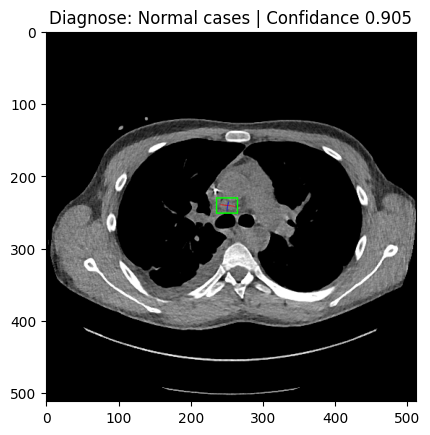

In [63]:
# prediction label
loaded_model_10.eval()
with torch.inference_mode():
  output = loaded_model_10(image_tensor)
  prob = torch.softmax(output, dim=1)
  pred_class = prob.argmax(dim=1).item()
  label = base_dataset.classes[pred_class]
plt.imshow(image)
plt.title(f"Diagnose: {label} | Confidance {prob.squeeze()[pred_class]:.3f}");

## 12. Conclusion

1. Training with too low epoch made the model underfit. The increase of the epoch helps the model to learn feature that more representative until a certain point.
2. Adam optimizer gave the fastes convergence and training stability, while SGD with momentum give a competitive result. SGD without momentum tend to converegce slowly.
3. The increase of hidden units helps the model to overcome underfit in early stage. But, model with higher complexity shows the indication of overfit, indicated by the gap between training and validation performance. Model with moderate complexity gives the trade of between reprensetation and generalization.
